# XLand-MiniGrid Data Analysis


In [36]:
from nicewebrl import data_analysis
from flax import serialization
import jax

In [87]:
from nicewebrl.utils import read_all_records

file_path = "/Users/vikramgoddla/nicewebrl_LLM_EnvStage/nicewebrl/examples/xland-LLM-assistant/data/user_data_4066198672.msgpack"
data_dicts = await read_all_records(file_path)

In [88]:
len(data_dicts)

154

In [89]:
from collections import Counter

# Count field frequencies inside "data"
field_counts = Counter(k for d in data_dicts for k in d.get('data', {}).keys())
print(field_counts.most_common(20))

# Peek at the last few records to see why [-1] didn't have action_taken_time
for d in data_dicts[-5:]:
    print(d.get('type'), list(d.get('data', {}).keys()))

[('image_seen_time', 153), ('action_taken_time', 153), ('computer_interaction', 153), ('action_name', 153), ('action_idx', 153), ('timelimit', 153), ('timestep', 153), ('event', 153), ('How helpful was the AI?', 1), ('How human-like was the AI?', 1)]
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event']
None ['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event']
None ['How helpful was the AI?', 'How human-like was the AI?']


In [90]:
def has_keys(d, *ks):
    return all(k in d.get('data', {}) for k in ks)

action_recs = [d for d in data_dicts
               if has_keys(d, 'image_seen_time', 'action_taken_time')]
print(len(action_recs), "action timesteps")

153 action timesteps


In [91]:
from nicewebrl import time_diff

def has_str(d, key):
    v = d.get('data', {}).get(key)
    return isinstance(v, str) and len(v) > 0

# keep only *valid* action records with both times present as strings
action_recs = [
    d for d in data_dicts
    if has_str(d, 'image_seen_time') and has_str(d, 'action_taken_time')
]

# FIRST valid image_seen_time anywhere in the stream
first_image_ts = next(
    d['data']['image_seen_time'] for d in data_dicts if has_str(d, 'image_seen_time')
)

# LAST valid action_taken_time among action records
last_action_ts = next(
    d['data']['action_taken_time'] for d in reversed(action_recs)
)

start_end_sec = time_diff(first_image_ts, last_action_ts) / 1000
print(f"Total seconds from first timestep to last action: {start_end_sec:.2f}")

pair_ms = [
    time_diff(d['data']['image_seen_time'], d['data']['action_taken_time'])
    for d in action_recs
]
total_timestep_sec = sum(pair_ms) / 1000
print(f"Total seconds across image–action pairs: {total_timestep_sec:.2f}")

Total seconds from first timestep to last action: 47.51
Total seconds across image–action pairs: 59.04


In [92]:
from pprint import pprint

datum = data_dicts[0]
print("-----")
pprint(list(datum.keys()))
print("--- data ---")
pprint(list(datum["data"].keys()))

-----
['stage_idx', 'session_id', 'data', 'user_data', 'metadata', 'name', 'body']
--- data ---
['image_seen_time',
 'action_taken_time',
 'computer_interaction',
 'action_name',
 'action_idx',
 'timelimit',
 'timestep',
 'event']


In [93]:
print("------")

for key in [
  # "id",  # time-step idx. global
  "session_id",  # browser session id
  "stage_idx",
]:
  print(key, ":", datum[key])

print("--- data ---")
for key in [
  "image_seen_time",
  "action_taken_time",
  "computer_interaction",
  "action_name",
  "action_idx",
]:
  print(key, ":", datum["data"][key])

------
session_id : 9fea8194-7ed6-4b87-8346-f4dfdbd06610
stage_idx : 1
--- data ---
image_seen_time : 2025-10-19T17:04:06.481Z
action_taken_time : 2025-10-19T17:04:08.156Z
computer_interaction : ArrowUp
action_name : Forward
action_idx : 0


In [94]:
type(datum['data'].keys())
datum['data'].keys()

dict_keys(['image_seen_time', 'action_taken_time', 'computer_interaction', 'action_name', 'action_idx', 'timelimit', 'timestep', 'event'])

In [95]:
datum["metadata"]  # remember, this is for the VERY FIRST timestep of this episode

{'stage_number': 1,
 'type': 'EnvStage',
 'unique_id': 'stage_e819e85ac368471d91675a536e0d4629',
 'nsteps': 2,
 'nepisodes': 1,
 'nsuccesses': 0}

In [96]:
datum["user_data"]

{'user_id': 4066198672, 'age': 19, 'sex': 'Male'}

In [97]:
def is_str(v): return isinstance(v, str) and len(v) > 0

img_idxs, img_ts = [], []
act_idxs, act_ts = [], []
for i, d in enumerate(data_dicts):
    dd = d.get('data', {})
    if is_str(dd.get('image_seen_time')):
        img_idxs.append(i); img_ts.append(dd['image_seen_time'])
    if is_str(dd.get('action_taken_time')):
        act_idxs.append(i); act_ts.append(dd['action_taken_time'])

print(f"records={len(data_dicts)}  images={len(img_idxs)}  actions={len(act_idxs)}")
print("first image idx:", img_idxs[0] if img_idxs else None, "| ts:", img_ts[0] if img_ts else None)
print("first action idx:", act_idxs[0] if act_idxs else None, "| ts:", act_ts[0] if act_ts else None)
print("image idxs (first 10):", img_idxs[:10])
print("action idxs (first 10):", act_idxs[:10])


records=154  images=153  actions=153
first image idx: 0 | ts: 2025-10-19T17:04:06.481Z
first action idx: 0 | ts: 2025-10-19T17:04:08.156Z
image idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
action idxs (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [98]:
datum = data_dicts[0]["data"]
action_taken: int = datum["action_idx"]
image_seen_time: str = datum["image_seen_time"]
action_taken_time: str = datum["action_taken_time"]
reaction_time: float = data_analysis.compute_reaction_time(datum)

print(f"Reaction time: {reaction_time:.2f} milliseconds")

Reaction time: 1675.00 milliseconds


In [99]:
import jax
from experiment_structure import jax_env, env_params, render_fn

example_timestep = jax_env.reset(key=jax.random.PRNGKey(0), params=env_params)

Compiling environment reset and step functions.
	reset time: 0.5380089282989502
	step time: 4.870867967605591
Compiling multi-render function.
	time: 0.8754281997680664


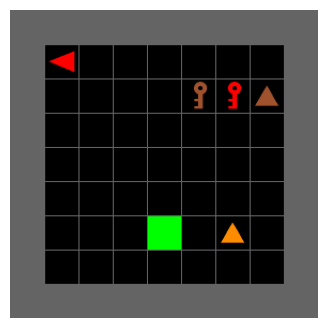

In [106]:
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
from flax import serialization

# 1) Reload latest experiment_structure so we pick up the top-down render_fn
import experiment_structure as exp
reload(exp)
RENDER = exp.render_fn  # this should be the top-down renderer now

def show_one_timestep_topdown(data_dicts, example_timestep, idx=0):
    assert 0 <= idx < len(data_dicts), f"idx {idx} out of range (len={len(data_dicts)})"
    rec = data_dicts[idx]
    dd  = rec.get("data", {}) or {}

    # reconstruct timestep
    ts_bytes = dd["timestep"]
    timestep = serialization.from_bytes(example_timestep, ts_bytes)

    # call top-down renderer
    img = np.asarray(RENDER(timestep))
    # defensive fallback if the wrong renderer was still bound somehow
    if img.ndim != 3 or img.shape[-1] != 3:
        from render import render as TOPDOWN_RENDER  # your professor's renderer
        img = np.asarray(TOPDOWN_RENDER(timestep.state.grid, timestep.state.agent), dtype=np.uint8)

    # display
    plt.figure(figsize=(4, 4))
    plt.imshow(img.astype(np.uint8))
    plt.axis("off")
    plt.show()

# Example
show_one_timestep_topdown(data_dicts, example_timestep, idx=0)

In [101]:
rec0_keys = sorted((data_dicts[0].get("data") or {}).keys())
print(rec0_keys)

['action_idx', 'action_name', 'action_taken_time', 'computer_interaction', 'event', 'image_seen_time', 'timelimit', 'timestep']


In [109]:
# --- Simple transcript dumper for llm_chat_history ---

def _get_hist(rec):
    """Returns history as a list[dict] or None."""
    dd = rec.get("data", {}) or {}
    hist = (dd.get("event", {}) or {}).get("args", {}).get("llm_chat_history")
    if not hist:
        return None
    return hist if isinstance(hist, list) else [hist]

# Pick the record with the longest history per stage
best = {}  # stage -> (turn_count, hist, rec_idx)
for i, rec in enumerate(data_dicts):
    stage = rec.get("name", "<unknown>")
    hist = _get_hist(rec)
    if not hist:
        continue
    cur = best.get(stage)
    if cur is None or len(hist) > cur[0]:
        best[stage] = (len(hist), hist, i)

if not best:
    print("No llm_chat_history found in any record.")
else:
    for stage, (n, hist, idx) in sorted(best.items()):
        print(f"\n=== {stage} (record #{idx}) — {n} turn(s) ===")
        for t, turn in enumerate(hist, start=1):
            ts = turn.get("timestamp", "")
            prompt = (turn.get("prompt") or "").strip()
            resp   = (turn.get("response") or "").strip()
            print(f"\n[{t}] {ts}")
            print(f"User: {prompt}")
            print(f"AI  : {resp}")


=== Environment 1 (record #12) — 1 turn(s) ===

[1] 2025-10-19T17:04:20.427942+00:00
User: what's the goal here?
AI  : The goal is to combine the grey pyramid and white pyramid, which are positioned near the agent, to achieve the objective. Specifically, you need to find the grey pyramid (available in the initial tiles) and the white pyramid (also in the initial tiles) and complete the task described.


In [110]:
# print(data_dicts[0].keys())
# print(data_dicts[0]['data'].keys())
import jax
from pprint import pprint

pprint(jax.tree.map(lambda x: type(x), data_dicts[19]))


{'body': <class 'str'>,
 'data': {'action_idx': <class 'int'>,
          'action_name': <class 'str'>,
          'action_taken_time': <class 'str'>,
          'computer_interaction': <class 'str'>,
          'event': {'args': {'AT_TARGET': <class 'int'>,
                             'BUBBLING_PHASE': <class 'int'>,
                             'CAPTURING_PHASE': <class 'int'>,
                             'DOM_KEY_LOCATION_LEFT': <class 'int'>,
                             'DOM_KEY_LOCATION_NUMPAD': <class 'int'>,
                             'DOM_KEY_LOCATION_RIGHT': <class 'int'>,
                             'DOM_KEY_LOCATION_STANDARD': <class 'int'>,
                             'NONE': <class 'int'>,
                             '_vts': <class 'int'>,
                             'altKey': <class 'bool'>,
                             'bubbles': <class 'bool'>,
                             'cancelBubble': <class 'bool'>,
                             'cancelable': <class 'bool'>,
  